<a href="https://colab.research.google.com/github/vandanasri/MLProjectRepo/blob/main/p04-Vandana/audits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [148]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [149]:
# import New York City Airbnb Open Dataset
df = pd.read_csv("/content/AB_NYC_2019.csv", skipinitialspace=True)

In [150]:
df.shape

(48895, 16)

Adult dataset has 16 rows and 48895 columns

In [151]:
# Column names
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [152]:
# There is no duplicate columns
df.columns.has_duplicates

False

In [153]:
df.head(10)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.65,-73.97,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75,-73.98,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.81,-73.94,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.69,-73.96,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.80,-73.94,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
5,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Manhattan,Murray Hill,40.75,-73.97,Entire home/apt,200,3,74,2019-06-22,0.59,1,129
6,5121,BlissArtsSpace!,7356,Garon,Brooklyn,Bedford-Stuyvesant,40.69,-73.96,Private room,60,45,49,2017-10-05,0.40,1,0
7,5178,Large Furnished Room Near B'way,8967,Shunichi,Manhattan,Hell's Kitchen,40.76,-73.98,Private room,79,2,430,2019-06-24,3.47,1,220
8,5203,Cozy Clean Guest Room - Family Apt,7490,MaryEllen,Manhattan,Upper West Side,40.80,-73.97,Private room,79,2,118,2017-07-21,0.99,1,0
9,5238,Cute & Cozy Lower East Side 1 bdrm,7549,Ben,Manhattan,Chinatown,40.71,-73.99,Entire home/apt,150,1,160,2019-06-09,1.33,4,188


In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

There are 10 numerical features and 6 categorical features


In [155]:
# Checking for null values in dataset
df.isna().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


'Name' has 16 missing values.

'host_name' has 21 missing values.

'last_review' has 10052 missing values

'reviews_per_month' has 10052 missing values.

In [156]:
(df=="?").sum()

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


Dropping some unwanted columns because they add no meaning to the prediction .

Here, Target column is 'price'

In [157]:
# drop of unwanted columns
df = df.drop(columns=['id', 'name', 'host_id', 'host_name'])
df.columns

Index(['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude',
       'room_type', 'price', 'minimum_nights', 'number_of_reviews',
       'last_review', 'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

R-1 Below is the table, which show all four required properties of Airbnb dataset.

In [158]:
air_bnb_prop_table = pd.DataFrame(
    {
        "data_type": df.dtypes,
        "missing_count":df.isna().sum(),
        "missing_percentage":(df.isna().mean()*100).round(2),
        "unique_count":df.nunique()
    }
)

air_bnb_prop_table

,data_type,missing_count,missing_percentage,unique_count
neighbourhood_group,object,0,0.00,5
neighbourhood,object,0,0.00,221
latitude,float64,0,0.00,19048
longitude,float64,0,0.00,14718
room_type,object,0,0.00,3
price,int64,0,0.00,674
minimum_nights,int64,0,0.00,109
number_of_reviews,int64,0,0.00,394
last_review,object,10052,20.56,1764
reviews_per_month,float64,10052,20.56,937


## R-2 Audit

### get maximun and min for numeric columns and categorical, get Numerical and categorical columns seperatly.

In [159]:
#numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns
# Categorical columns
categorical_cols = df.select_dtypes(exclude=np.number).columns
print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: Index(['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')
Categorical columns: Index(['neighbourhood_group', 'neighbourhood', 'room_type', 'last_review'], dtype='object')


In [160]:
# min columns
df[numerical_cols].min()

,0
latitude,40.50
longitude,-74.24
price,0.00
minimum_nights,1.00
number_of_reviews,0.00
reviews_per_month,0.01
calculated_host_listings_count,1.00
availability_365,0.00


In [161]:
# Print only the top 3 category names for each categorical column
def get_top_3_categories_list(cat_columns:list):
  top_3_categories_list = []
  for col in cat_columns:
    top_3_categories = df[col].value_counts().head(3)
    top_3_categories_list.append(top_3_categories)
  return top_3_categories_list

In [162]:
#list top top 3 values of categorical columns
display(get_top_3_categories_list(categorical_cols))

[neighbourhood_group
 Manhattan    21661
 Brooklyn     20104
 Queens        5666
 Name: count, dtype: int64,
 neighbourhood
 Williamsburg          3920
 Bedford-Stuyvesant    3714
 Harlem                2658
 Name: count, dtype: int64,
 room_type
 Entire home/apt    25409
 Private room       22326
 Shared room         1160
 Name: count, dtype: int64,
 last_review
 2019-06-23    1413
 2019-07-01    1359
 2019-06-30    1341
 Name: count, dtype: int64]

Outliner

In [189]:
from numpy._core.defchararray import lower
# find outliers
def find_outliers_IQR(data):
    data.dropna()
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    outlier = ((data < lower_limit) | (data > upper_limit)).sum()
    return outlier

find_outliers_IQR(df[numerical_cols])

,0
latitude,425
longitude,2833
price,2972
minimum_nights,6607
number_of_reviews,6021
reviews_per_month,1793
calculated_host_listings_count,7081
availability_365,0


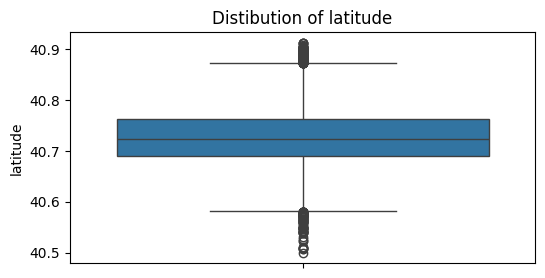

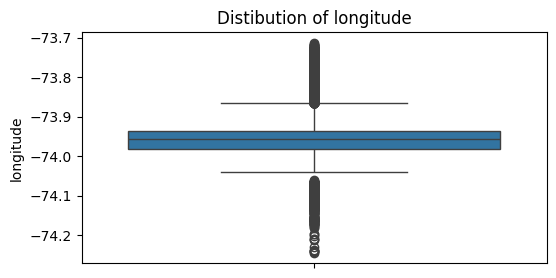

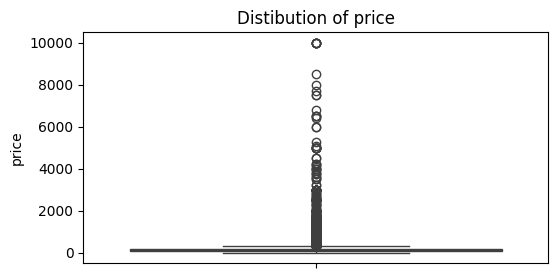

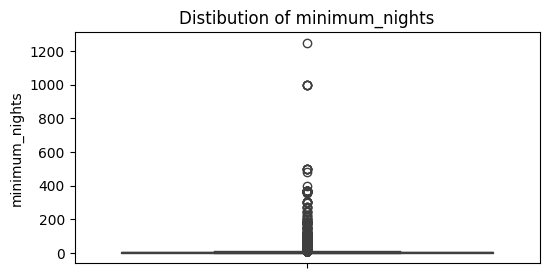

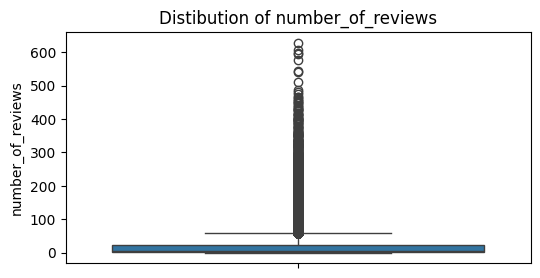

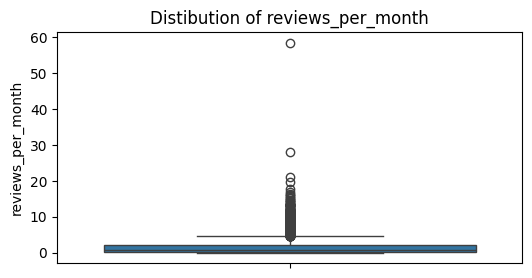

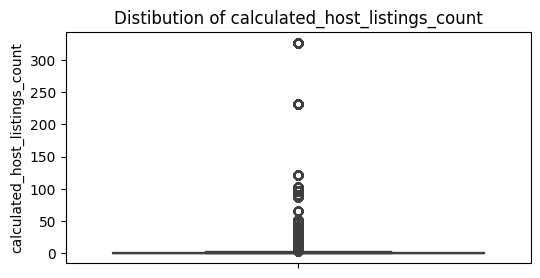

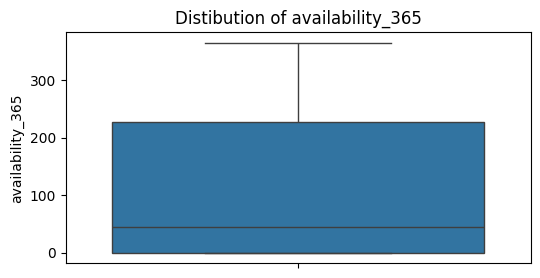

Outliers:  
 latitude                           425
longitude                         2833
price                             2972
minimum_nights                    6607
number_of_reviews                 6021
reviews_per_month                 1793
calculated_host_listings_count    7081
availability_365                     0
dtype: int64


In [193]:
# checking outliers for all the numerical columns using histogram
for n_col in numerical_cols:
  plt.figure(figsize=(6,3))
  plt.title(f'Distibution of {n_col}')
  sns.boxplot(df[n_col])
  plt.show()
print('Outliers:  \n',find_outliers_IQR(df[numerical_cols]))

